In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train.shape

(50000, 32, 32, 3)

In [3]:
x_test.shape

(10000, 32, 32, 3)

In [4]:
y_train[:6]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1]], dtype=uint8)

In [5]:
y_train = y_train.reshape(-1,)
y_train[:6]

array([6, 9, 9, 4, 1, 1], dtype=uint8)

In [6]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [7]:
def plot_sample(x, y, index):
    plt.figure(figsize=(2,2))
    plt.imshow(x_train[index])
    plt.xlabel(classes[y[index]])

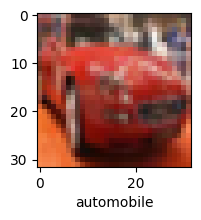

In [8]:
plot_sample(x_train, y_train, 5)

In [9]:
x_train = x_train / 255
x_test = x_test / 255

In [10]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1500, activation='relu'),
    layers.Dense(500, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann.fit(x_train, y_train, epochs=5)

Epoch 1/5
1563/1563 [==============================] - 11s 6ms/step - loss: 1.8174 - accuracy: 0.3490
Epoch 2/5
1563/1563 [==============================] - 8s 5ms/step - loss: 1.6184 - accuracy: 0.4255
Epoch 3/5
1563/1563 [==============================] - 8s 5ms/step - loss: 1.5329 - accuracy: 0.4531
Epoch 4/5
1563/1563 [==============================] - 8s 5ms/step - loss: 1.4684 - accuracy: 0.4810
Epoch 5/5
1563/1563 [==============================] - 8s 5ms/step - loss: 1.4172 - accuracy: 0.4982


## After end of 5 epochs, accuracy is at around 49% 

In [11]:
ann.evaluate(x_test, y_test)

313/313 [==============================] - 2s 4ms/step - loss: 1.4700 - accuracy: 0.4774


[1.469986915588379, 0.477400004863739]

In [12]:
from sklearn.metrics import confusion_matrix , classification_report
y_pred = ann.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 [==============================] - 1s 2ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.55      0.60      0.57      1000
           1       0.44      0.81      0.57      1000
           2       0.32      0.48      0.38      1000
           3       0.38      0.25      0.30      1000
           4       0.48      0.38      0.42      1000
           5       0.37      0.45      0.41      1000
           6       0.57      0.45      0.50      1000
           7       0.66      0.47      0.55      1000
           8       0.76      0.41      0.53      1000
           9       0.54      0.49      0.51      1000

    accuracy                           0.48     10000
   macro avg       0.51      0.48      0.48     10000
weighted avg       0.51      0.48      0.48     10000



In [13]:
cnn = models.Sequential([
    # cnn layers
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(500, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 [==============================] - 16s 5ms/step - loss: 1.3683 - accuracy: 0.5093
Epoch 2/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9851 - accuracy: 0.6537
Epoch 3/10
1563/1563 [==============================] - 7s 5ms/step - loss: 0.8079 - accuracy: 0.7186
Epoch 4/10
1563/1563 [==============================] - 7s 4ms/step - loss: 0.6650 - accuracy: 0.7665
Epoch 5/10
1563/1563 [==============================] - 8s 5ms/step - loss: 0.5281 - accuracy: 0.8175
Epoch 6/10
1563/1563 [==============================] - 8s 5ms/step - loss: 0.4030 - accuracy: 0.8618
Epoch 7/10
1563/1563 [==============================] - 8s 5ms/step - loss: 0.2878 - accuracy: 0.8999
Epoch 8/10
1563/1563 [==============================] - 8s 5ms/step - loss: 0.2022 - accuracy: 0.9304
Epoch 9/10
1563/1563 [==============================] - 7s 4ms/step - loss: 0.1521 - accuracy: 0.9480
Epoch 10/10
1563/1563 [==============================] - 7s 4ms/step - loss: 0.12

## Here we can see After end of 5 epochs, accuracy is at around 80% 

In [14]:
cnn.evaluate(x_test, y_test)

313/313 [==============================] - 2s 4ms/step - loss: 1.5061 - accuracy: 0.6997


[1.5060702562332153, 0.6996999979019165]

In [15]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

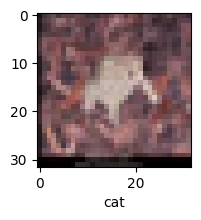

In [16]:
plot_sample(x_test, y_test, 224)

In [17]:
y_pred = cnn.predict(x_test)
y_pred[:3]

313/313 [==============================] - 1s 2ms/step


array([[4.0606980e-09, 4.6444435e-02, 2.8255247e-04, 9.0853608e-01,
        1.7764011e-06, 4.4681825e-02, 1.1237328e-06, 4.8887072e-10,
        5.2153278e-05, 2.1671941e-08],
       [6.7054265e-07, 9.5881599e-01, 2.5295017e-13, 2.5307891e-14,
        5.2107002e-18, 7.8942168e-19, 1.8578441e-14, 4.8491473e-19,
        4.1181862e-02, 1.5366875e-06],
       [5.5436637e-02, 4.2399384e-02, 1.1788274e-07, 1.7626675e-06,
        2.8279694e-04, 2.4074268e-08, 1.5721560e-05, 2.3047162e-06,
        8.8646615e-01, 1.5395087e-02]], dtype=float32)

In [18]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 1, 8, 0, 4]

In [19]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [20]:
classes[y_classes[224]]

'deer'

In [21]:
print("Classification Report: \n", classification_report(y_test, y_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.70      0.78      0.73      1000
           1       0.77      0.85      0.81      1000
           2       0.62      0.57      0.60      1000
           3       0.50      0.52      0.51      1000
           4       0.63      0.69      0.66      1000
           5       0.64      0.54      0.59      1000
           6       0.83      0.72      0.77      1000
           7       0.73      0.77      0.75      1000
           8       0.78      0.81      0.79      1000
           9       0.81      0.74      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000

